In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub
 
path = kagglehub.dataset_download(
    "jessemostipak/hotel-booking-demand"
)
 
print(path)

df = pd.read_csv(os.path.join(path, "hotel_bookings.csv"))

c:\Projekt Data Science\flotation-silica-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\malin\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1


## Skapa tidsvariabler

I datasetet finns inte bokningsdatum men det kan skapas utifrån dessa variabler:

`arrival_date_day_of_month` -> Day of the month of the arrival date  
`arrival_date_month` -> Month of arrival date with 12 categories: “January” to “December”  
`arrival_date_year` -> Year of arrival date  
`lead_time` -> Number of days that elapsed between the entering date of the booking into the PMS and the arrival date  

Vi skapar också `outcome_date` från `reservation_status_date`, som anger när bokningens status senast ändrades:

- avbokningsdatum för avbokade bokningar
- utcheckningsdatum för genomförda
- ankomstdatum för no-shows  

`outcome_date` används bara i EDA:n och aldrig i modellen, eftersom den avslöjar utfallet.

In [3]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-"
    + df["arrival_date_month"].astype(str) + "-"
    + df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
)
df["booking_date"] = df["arrival_date"] - pd.to_timedelta(df["lead_time"], unit="D")
df["outcome_date"] = pd.to_datetime(df["reservation_status_date"])

# Rimlighetskontroller
canc = df[df["is_canceled"] == 1]
print("Utfall före bokningen:", (df["outcome_date"] < df["booking_date"]).sum())
print("Avbokningar efter ankomsten:", (canc["outcome_date"] > canc["arrival_date"]).sum())

Utfall före bokningen: 0
Avbokningar efter ankomsten: 0


### Observation

Inget utfall ligger före bokningsdatumet, och ingen bokning är avbokad efter ankomstdatumet.  
Det sista betyder att om en bokning avbokas eller blir en no-show är känt senast vid ankomsten.

**Vilka bokningar får modellen lära sig av?**  
Modellen gör sin prognos vid en viss tidpunkt T och får då bara lära sig av bokningar vars utfall var känt före T.  
Eftersom utfallet är känt senast vid ankomsten tränas modellen på bokningar med ankomst före T.

Avbokningsdatumet används inte, trots att det ofta är känt tidigare, eftersom avbokade bokningar då skulle komma med i träningsdata före genomförda och andelen avbokade skulle bli för hög.

## Tidsperiod och bokningar över tid

Vi vill se datumintervall för bokningar och ankomster

In [ ]:
df[["booking_date", "arrival_date"]].agg(["min", "max"])

,booking_date,arrival_date
min,2013-06-24,2015-07-01
max,2017-08-31,2017-08-31


### Observation

Datasetet omfattar ankomster mellan 1 juli 2015 och 31 augusti 2017. Bokningsdatumen börjar tidigare, i juni 2013, eftersom vissa bokningar görs upp till två år före ankomst.  

Vi plottar antal bokningar per månad för att undersöka variation i datan.

<Axes: xlabel='booking_date'>

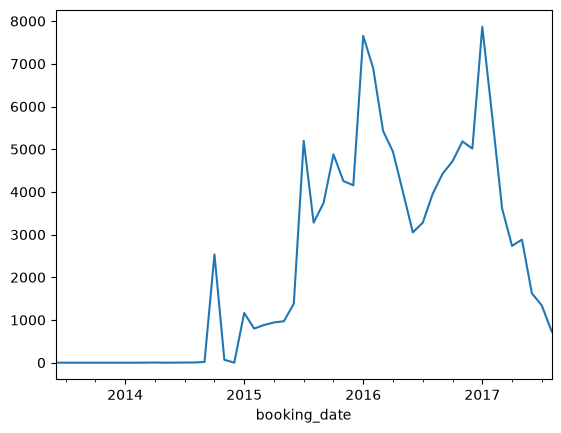

In [ ]:
df.set_index("booking_date").resample("MS").size().plot() # (MS = Month Start)

### Observation

- **Början:** Före juli 2015 finns bara bokningar med lång ledtid, eftersom ankomsterna börjar då. Antalet är därför lågt fram till sommaren 2015.
- **Slutet:** Bokningar från 2017 finns bara med om ankomsten skedde senast i augusti 2017. Kurvan faller därför brant under 2017.
- **Säsong:** Topparna i januari 2016 och januari 2017 visar att många bokar sommarens resor tidigt på året.
- **Oktober 2014:** En avvikande topp med cirka 2 500 bokningar, som undersöks nedan.

Bokningarna är mest kompletta ungefär från mitten av 2015 till slutet av 2016. Testperioden måste därför ligga så att de flesta bokningar hinner ha sin ankomst innan datan tar slut.

Vi undersöker peak-perioden hösten 2014 mer i detalj.

In [ ]:
peak_2014 = df[(df.booking_date >= "2014-09-01") & (df.booking_date < "2014-11-01")]
print(peak_2014["hotel"].value_counts())
print("Andel avbokade:", round(peak_2014["is_canceled"].mean(), 3))
print(peak_2014["deposit_type"].value_counts())
print(peak_2014["agent"].value_counts().head())
print("Andel dubbletter:", round(peak_2014.duplicated().mean(), 3))

hotel
City Hotel      2509
Resort Hotel      44
Name: count, dtype: int64
Andel avbokade: 0.919
deposit_type
Non Refund    1562
No Deposit     991
Name: count, dtype: int64
agent
1.0     2065
6.0      350
5.0       74
21.0      16
40.0       9
Name: count, dtype: int64
Andel dubbletter: 0.918


### Observation

Bokningarna som gjordes i september–oktober 2014 skiljer sig tydligt från resten av datan:

- Nästan alla (2 509 av 2 553) gäller City Hotel.
- 92 % avbokades, jämfört med 37 % i hela datan.
- 61 % är ej återbetalningsbara, jämfört med 12 % i hela datan.
- Cirka 80 % är bokade via samma resebyrå (agent 1).
- 92 % är identiska rader.

Mönstret tyder på att det inte är enskilda gästbokningar utan stora block av rum som en resebyrå reserverade i förväg och sedan avbokade.  

Bokningar gjorda före juli 2015 är ofullständiga, eftersom bara bokningar med lång ledtid finns med, och de innehåller toppen 2014 med ovanligt hög avbokningsandel.